# K-Nearest Neighbors

Binary classification on California housing: `median_house_value > median`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_curve, auc)

data_df = pd.read_csv("housing.csv")
data_df['total_bedrooms'] = data_df['total_bedrooms'].fillna(data_df['total_bedrooms'].median())
data_df = pd.get_dummies(data_df, columns=['ocean_proximity'], dtype=float)

threshold = data_df['median_house_value'].median()
y = (data_df['median_house_value'] > threshold).astype(int).to_numpy()
X = data_df.drop(columns=['median_house_value']).to_numpy()

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, shuffle=True, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(13828, 13) (6812, 13)


## Baseline

`k=5`, defaults. Standardized features matter a lot here because the prediction depends entirely on Euclidean distance:

$$d(x, x') = \sqrt{\sum_i (x_i - x'_i)^2}$$

Without standardization, features with bigger ranges (income, population) dominate the distance and the rest barely contribute.

In [2]:
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
y_proba = knn.predict_proba(X_test)[:, 1]

print(f"Test acc: {accuracy_score(y_test, y_pred):.4f}")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['Below', 'Above']))

Test acc: 0.8520
[[2958  449]
 [ 559 2846]]
              precision    recall  f1-score   support

       Below       0.84      0.87      0.85      3407
       Above       0.86      0.84      0.85      3405

    accuracy                           0.85      6812
   macro avg       0.85      0.85      0.85      6812
weighted avg       0.85      0.85      0.85      6812



## k sweep

Small k = high variance (noisy boundary), large k = high bias (oversmoothed). Pick the k that minimizes test error. The optimum is usually somewhere between k=15 and k=50 on data this size.

k=1    train=1.0000 test=0.8338


k=3    train=0.9139 test=0.8506


k=5    train=0.8937 test=0.8520


k=7    train=0.8863 test=0.8542


k=11   train=0.8770 test=0.8544


k=15   train=0.8711 test=0.8551


k=25   train=0.8589 test=0.8532


k=51   train=0.8468 test=0.8484


k=101  train=0.8346 test=0.8379


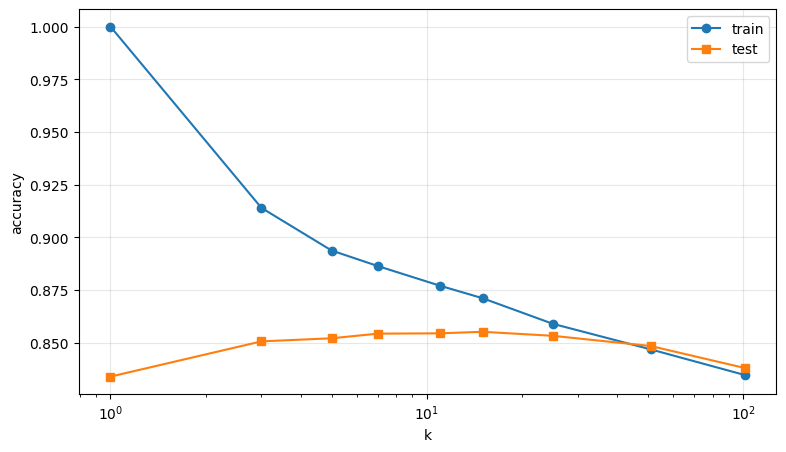

Best k: 15


In [3]:
ks = [1, 3, 5, 7, 11, 15, 25, 51, 101]
train_acc, test_acc = [], []

for k in ks:
    m = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    m.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, m.predict(X_train)))
    test_acc.append(accuracy_score(y_test, m.predict(X_test)))
    print(f"k={k:<4} train={train_acc[-1]:.4f} test={test_acc[-1]:.4f}")

plt.figure(figsize=(9, 5))
plt.plot(ks, train_acc, 'o-', label='train')
plt.plot(ks, test_acc, 's-', label='test')
plt.xscale('log')
plt.xlabel('k')
plt.ylabel('accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

best_k = ks[int(np.argmax(test_acc))]
print(f"Best k: {best_k}")

## Distance metric and weighting

Three distance metrics:

- **Euclidean**: $\sqrt{\sum_i (x_i - x'_i)^2}$
- **Manhattan**: $\sum_i |x_i - x'_i|$
- **Chebyshev**: $\max_i |x_i - x'_i|$

And uniform vs. distance weighting — distance weighting gives each neighbor weight $1/d_i$ so closer points count more.

In [4]:
for metric in ['euclidean', 'manhattan', 'chebyshev']:
    for weights in ['uniform', 'distance']:
        m = KNeighborsClassifier(n_neighbors=best_k, metric=metric,
                                 weights=weights, n_jobs=-1)
        m.fit(X_train, y_train)
        te = accuracy_score(y_test, m.predict(X_test))
        print(f"{metric:<10} {weights:<9} test={te:.4f}")

euclidean  uniform   test=0.8551


euclidean  distance  test=0.8583


manhattan  uniform   test=0.8641


manhattan  distance  test=0.8674
chebyshev  uniform   test=0.8517


chebyshev  distance  test=0.8532


## From-scratch KNN

Brute-force pairwise distances, take the k smallest, majority vote. Matches `src/rice_ml/supervised_ml/knn.py` — slow but transparent. Subsampled at predict time since it computes distances to every training point per query.

In [5]:
from rice_ml.supervised_ml import KNN as KNNScratch

rng = np.random.default_rng(42)
sub = rng.choice(len(X_test), 1000, replace=False)

scratch = KNNScratch(k=best_k).fit(X_train, y_train)
preds = scratch.predict(X_test[sub])
print(f"Scratch KNN (subset of 1000) test acc: {accuracy_score(y_test[sub], preds):.4f}")

Scratch KNN (subset of 1000) test acc: 0.8630


## Decision boundary on two features

2D version on `median_income` and `housing_median_age` so I can see KNN's characteristic ragged, locally-adaptive boundary. Unlike a linear model, the boundary follows the data wherever it goes.

2-feature test acc: 0.7563


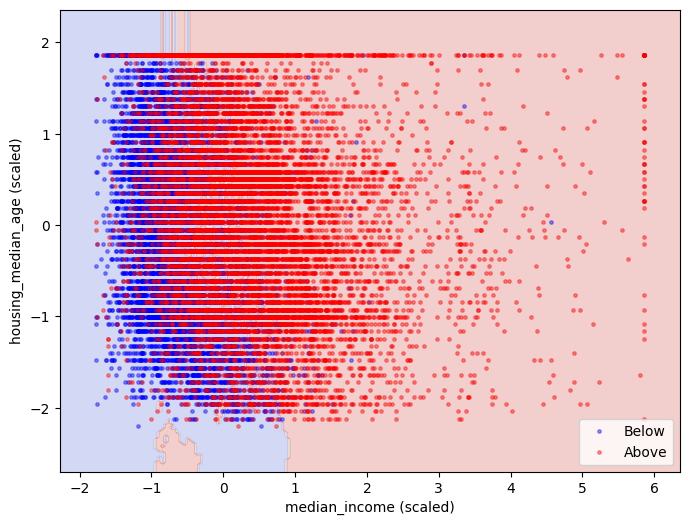

In [6]:
raw = pd.read_csv("housing.csv")
raw['total_bedrooms'] = raw['total_bedrooms'].fillna(raw['total_bedrooms'].median())
thr = raw['median_house_value'].median()
y2 = (raw['median_house_value'] > thr).astype(int).to_numpy()
X2 = StandardScaler().fit_transform(raw[['median_income', 'housing_median_age']].to_numpy())

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.33, random_state=42, stratify=y2
)

m2 = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1).fit(X2_train, y2_train)
print(f"2-feature test acc: {accuracy_score(y2_test, m2.predict(X2_test)):.4f}")

xx, yy = np.meshgrid(
    np.linspace(X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5, 200),
    np.linspace(X2[:, 1].min() - 0.5, X2[:, 1].max() + 0.5, 200),
)
Z = m2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
plt.scatter(X2[y2 == 0, 0], X2[y2 == 0, 1], s=6, c='blue', alpha=0.4, label='Below')
plt.scatter(X2[y2 == 1, 0], X2[y2 == 1, 1], s=6, c='red', alpha=0.4, label='Above')
plt.xlabel('median_income (scaled)')
plt.ylabel('housing_median_age (scaled)')
plt.legend()
plt.show()

## ROC

ROC + AUC using `predict_proba` from the best k. KNN's "probability" is just the fraction of neighbors in the positive class, so the curve is coarser than a logistic-regression ROC.

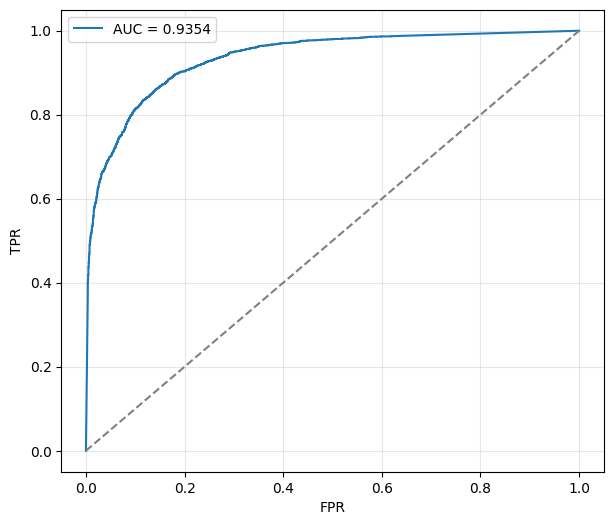

In [7]:
best = KNeighborsClassifier(n_neighbors=best_k, weights='distance', n_jobs=-1)
best.fit(X_train, y_train)
proba = best.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.grid(alpha=0.3)
plt.show()